# Replicate: Nvidia AI IOT NanoSAM
### .onnx (onnxruntime-gpu)
July 29th

NanoSAM is a Segment Anything (SAM) model variant that is capable of running in 🔥 real-time 🔥 on NVIDIA Jetson Orin Platforms with NVIDIA TensorRT.

In [1]:
# ------------------------------------------------------------ #
#                 Clean environment setup
# ------------------------------------------------------------ #

"""
# clean env wipe & activate
conda env remove --name nanosam_arm64 -y
conda deactivate
conda create -n nanosam_arm64 python=3.10 -y
conda activate nanosam_arm64

sudo apt update
sudo apt install libcudnn8 libcudnn8-dev
conda install -c conda-forge libstdcxx-ng=12 -y

"""

'\n# clean env wipe & activate\nconda env remove --name nanosam_arm64 -y\nconda deactivate\nconda create -n nanosam_arm64 python=3.10 -y\nconda activate nanosam_arm64\n\nsudo apt update\nsudo apt install libcudnn8 libcudnn8-dev\nconda install -c conda-forge libstdcxx-ng=12 -y\n\n'

In [2]:
# ------------------------------------------------------------ #
#        Installation of nanosam_arm64 repo requirements
# ------------------------------------------------------------ #

"""
git clone https://github.com/NVIDIA-AI-IOT/nanosam
cd nanosam
python3 setup.py develop --user


# More requirements
pip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 'opencv-python<4.9' jetson-stats


# Typical np version mismatch
pip uninstall -y numpy
pip install "numpy>=1.19.2,<2.0"
# pip install numpy==1.26.4 

# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)
pip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl

# download torchvision 0.20.0a0 (compatible with jp61 torch)
cd ~/vision/
python3 setup.py install
cd ~

# --- ONNXRUNTIME-GPU (build from scratch) ------------- #

cd ~/onnxruntime
pip uninstall onnxruntime -y
pip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall
pip install sympy==1.13.1 numpy==1.26.4

"""

# Debug Support

# Check your conda env GLIBCXX versions
# strings /home/copter/miniconda3/envs/nanosam_arm64/lib/python3.10/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6 | grep GLIBCXX

# trt2torch is apparently an issue and is obsolete for trt --version=10.3.0 
# additionally `pip install pycuda`

'\ngit clone https://github.com/NVIDIA-AI-IOT/nanosam\ncd nanosam\npython3 setup.py develop --user\n\n\n# More requirements\npip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 \'opencv-python<4.9\' jetson-stats\n\n\n# Typical np version mismatch\npip uninstall -y numpy\npip install "numpy>=1.19.2,<2.0"\n# pip install numpy==1.26.4 \n\n# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)\npip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl\n\n# download torchvision 0.20.0a0 (compatible with jp61 torch)\ncd ~/vision/\npython3 setup.py install\ncd ~\n\n# --- ONNXRUNTIME-GPU (build from scratch) ------------- #\n\ncd ~/onnxruntime\npip uninstall onnxruntime -y\npip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall\npip install sympy==1.13.1 numpy==1.26.4\n\n'

In [3]:
# from nanosam.utils.predictor import Predictor
import onnxruntime as ort
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import onnxruntime as ort
import os


In [ ]:
# video path (use for frame processing)

# Load the image
# image = PIL.open("/home/copter/jetson_benchmark/images/dogs.jpg")
image_path = "/home/copter/jetson_benchmark/images/dogs.jpg"
img = Image.open(image_path).convert("RGB")
img = img.resize((1024, 1024), resample=Image.BILINEAR)
w, h = img.size  # now both are 1024

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('on')  # Hide axes for cleaner display
plt.title("Dogs Image")
plt.show()

In [4]:
# Video processing

# video path (use for frame processing)
video_path = "/home/copter/Data/Cars are Traffic_Road Riding in Mexico City_Made with Clipchamp_1.mp4"

# Create a VideoCapture object
cap = cv2.VideoCapture(video_path)

# Check if video was opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

# Get video properties (frame width, height, and FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Define the codec and create a VideoWriter object to save the output
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # You can change the codec
out = cv2.VideoWriter('/home/copter/Data/output_video.mp4', fourcc, fps, (frame_width, frame_height))

In [ ]:
encoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_resnet18_image_encoder.onnx"
decoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_mobile_sam_mask_decoder.onnx"

# ---- Use optimized versions ----------------------

encoder_model_path=""
decoder_model_path=""

In [6]:
# Check available Execution Providers
print("--- Checking Available Execution Providers ---")
available_providers = ort.get_available_providers()
print(f"Available ONNX Runtime Execution Providers: {available_providers}")


# Set providers
preferred_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

# Configure session options (for threading)
session_options = ort.SessionOptions()
session_options.intra_op_num_threads = 6
session_options.inter_op_num_threads = 1
session_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL

try:
    print(f"Attempting to load encoder model with providers: {preferred_providers}")
    enc_sess = ort.InferenceSession(encoder_model_path, providers=preferred_providers, sess_options=session_options)
    print(f"Encoder session loaded. Actual provider used: {enc_sess.get_providers()}")

    print(f"Attempting to load decoder model with providers: {preferred_providers}")
    dec_sess = ort.InferenceSession(decoder_model_path, providers=preferred_providers, sess_options=session_options)
    print(f"Decoder session loaded. Actual provider used: {dec_sess.get_providers()}")

    # Verify which provider was actually chosen by ONNX Runtime
    if 'TensorrtExecutionProvider' in enc_sess.get_providers() and \
       'TensorrtExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.")
    elif 'CUDAExecutionProvider' in enc_sess.get_providers() and \
         'CUDAExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider (TensorRT not available or failed).")
    else:
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")

except Exception as e:
    print(f"An error occurred during session creation with preferred providers: {e}")
    # Fallback to CPU if preferred providers fail entirely
    print("Falling back to CPUExecutionProvider for both models.")
    try:
        enc_sess = ort.InferenceSession(encoder_model_path, providers=['CPUExecutionProvider'], sess_options=session_options)
        dec_sess = ort.InferenceSession(decoder_model_path, providers=['CPUExecutionProvider'], sess_options=session_options)
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider !!")
    except Exception as cpu_e:
        print(f"Fatal Error: Could not load models even with CPUExecutionProvider: {cpu_e}")

--- Checking Available Execution Providers ---
Available ONNX Runtime Execution Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Attempting to load encoder model with providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Encoder session loaded. Actual provider used: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Attempting to load decoder model with providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Decoder session loaded. Actual provider used: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.


2025-08-07 15:28:24.544733568 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:531 RegisterTensorRTPluginsAsCustomOps] The custom op domain name trt.plugins is already in session option.


In [7]:
# ---- SAMPLING EVERYTHING MODE GRID ------------------------------- # 

def segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings, grid_size=32):
    """
    Segment everything by sampling points on a grid
    """
    # Get decoder input names
    dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
    
    h, w = img.size[1], img.size[0]  # PIL image dimensions
    
    # Create grid of points (default it the full screen)
    x_coords = np.linspace(0, w-1, grid_size)
    y_coords = np.linspace(0, h-1, grid_size)
    
    all_masks = []
    all_scores = []
    
    # Sample points on grid (skip some to avoid too many)
    for x in x_coords[::4]:  
        for y in y_coords[::4]:
            # Create point prompt
            point_coords = np.array([[[x, y]]], dtype=np.float32)
            point_labels = np.array([[1]], dtype=np.float32)
            
            # Dummy inputs
            dummy_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
            dummy_has_mask_input = np.zeros((1,), dtype=np.float32)
            
            # Prepare decoder inputs
            dec_inputs = {
                dec_input_names[0]: image_embeddings,
                dec_input_names[1]: point_coords,
                dec_input_names[2]: point_labels,
                dec_input_names[3]: dummy_mask_input,
                dec_input_names[4]: dummy_has_mask_input,
            }
            
            # Run decoder
            scores, mask_out = dec_sess.run(None, dec_inputs)
            
            # Take best mask (highest score)
            best_idx = np.argmax(scores[0])
            if scores[0, best_idx] > 0.5:  # Quality threshold
                all_masks.append(mask_out[0, best_idx])
                all_scores.append(scores[0, best_idx])
    
    return all_masks, all_scores

# # Usage:
# all_masks, all_scores = segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings)
# print(f"Found {len(all_masks)} masks")

# # 3) Print shapes & count
# print("all_masks shape:", all_masks.shape)   # should be (1, N, H, W)
# print("mask_out (single mask) shape:", all_masks[0].shape)   # should be (1, N, H, W)
# print("all_scores   shape:", all_scores.shape)     # should be (1, N)
# n_masks = all_masks.shape[1]
# print("number of masks predicted:", n_masks)

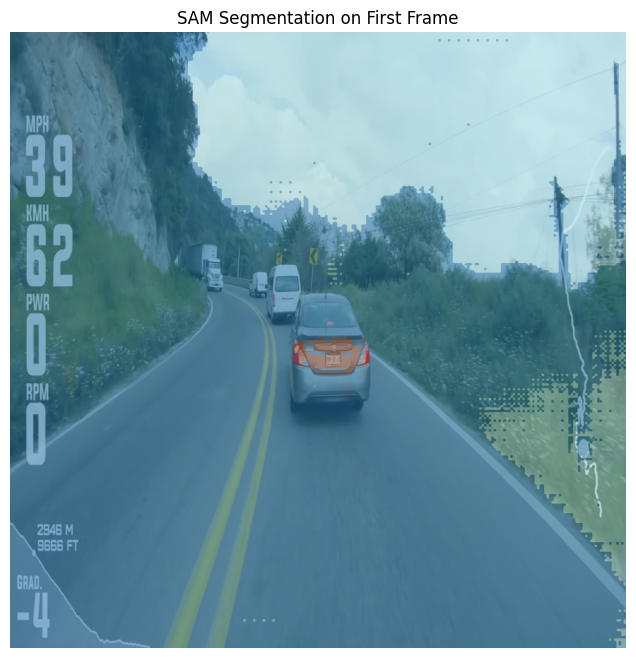

In [8]:
# Single Frame Processing

# Read the first frame
ret, frame = cap.read()

# Check if frame was read successfully
if ret:
    # Convert the frame to a PIL Image
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    # Resize the image and run the encoder
    img = img.resize((1024, 1024), resample=Image.BILINEAR)
    img_arr = np.array(img).astype(np.float32) / 255.0
    input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]
    
    # Run the SAM encoder
    enc_input_name = enc_sess.get_inputs()[0].name
    image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]
    
    # Run the "everything mode" segmentation
    all_masks, all_scores = segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings)
    
    # Create the blended mask
    img_array = np.array(img)
    h, w = img_array.shape[:2]
    segment_map = np.zeros((h, w), dtype=np.int32)
    score_threshold = 0.8
    segment_id = 1
    
    for mask, score in zip(all_masks, all_scores):
        if score < score_threshold:
            continue
        binary_mask = mask > 0
        if binary_mask.shape != (h, w):
            mask_pil = Image.fromarray((binary_mask * 255).astype(np.uint8))
            mask_pil = mask_pil.resize((w, h))
            binary_mask = np.array(mask_pil) > 128
        segment_map[binary_mask & (segment_map == 0)] = segment_id
        segment_id += 1
        
    # Create and display the blended result using Matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array)
    plt.imshow(segment_map, cmap='tab20', alpha=0.5)
    plt.title("SAM Segmentation on First Frame")
    plt.axis('off')
    plt.show()

# Release the video objects
cap.release()

In [ ]:
# # Full Video processing loop -------------

# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break # Break the loop if the video has ended
        
#     # --- YOUR EXISTING LOGIC GOES HERE ---
#     # Convert the frame to a PIL Image for your existing code
#     img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
#     # Resize the image and run the encoder
#     img = img.resize((1024, 1024), resample=Image.BILINEAR)
#     img_arr = np.array(img).astype(np.float32) / 255.0
#     input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]
    
#     # Run the SAM encoder
#     enc_input_name = enc_sess.get_inputs()[0].name
#     image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]
    
#     # Run the "everything mode" segmentation
#     all_masks, all_scores = segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings)
    
#     # Create and apply the blended mask
#     img_array = np.array(img)
#     h, w = img_array.shape[:2]
#     segment_map = np.zeros((h, w), dtype=np.int32)
#     score_threshold = 0.8
#     segment_id = 1
    
#     for mask, score in zip(all_masks, all_scores):
#         if score < score_threshold:
#             continue
#         binary_mask = mask > 0
#         if binary_mask.shape != (h, w):
#             mask_pil = Image.fromarray((binary_mask * 255).astype(np.uint8))
#             mask_pil = mask_pil.resize((w, h))
#             binary_mask = np.array(mask_pil) > 128
#         segment_map[binary_mask & (segment_map == 0)] = segment_id
#         segment_id += 1
        
#     # Create the blended frame (adjusting to OpenCV's BGR color space)
#     colored_segments = plt.cm.tab20(segment_map / segment_map.max())[:,:,:3]
#     blended_frame = img_array * 0.7 + colored_segments * 255 * 0.3
#     blended_frame = cv2.cvtColor(blended_frame.astype(np.uint8), cv2.COLOR_RGB2BGR)
    
#     # Write the processed frame to the output video file
#     out.write(blended_frame)
    
#     # Optional: Display the frame as it's being processed
#     cv2.imshow('Processed Video', blended_frame)
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# # Release the video objects and close all windows
# cap.release()
# out.release()
# cv2.destroyAllWindows()